In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import streamlit as st

c:\Users\RP DIGIPRESS\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [7]:
feargreed = pd.read_csv('../data/fear_greed_index.csv')
historical = pd.read_csv('../data/historical_data.csv')

In [8]:
feargreed.shape
feargreed.info()
feargreed.head()
feargreed.describe()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


,timestamp,value
count,2.644000e+03,2644.000000
mean,1.631899e+09,46.981089
std,6.597967e+07,21.827680
min,1.517463e+09,5.000000
25%,1.574811e+09,28.000000
50%,1.631900e+09,46.000000
75%,1.688989e+09,66.000000
max,1.746164e+09,95.000000


In [9]:
historical.shape
historical.info()
historical.head()
historical.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp
count,211224.000000,2.112240e+05,2.112240e+05,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,2.112240e+05
mean,11414.723350,4.623365e+03,5.639451e+03,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,1.737744e+12
std,29447.654868,1.042729e+05,3.657514e+04,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,8.689920e+09
min,0.000005,8.740000e-07,0.000000e+00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12
25%,4.854700,2.940000e+00,1.937900e+02,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,1.740000e+12
50%,18.280000,3.200000e+01,5.970450e+02,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,1.740000e+12
75%,101.580000,1.879025e+02,2.058960e+03,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,1.740000e+12
max,109004.000000,1.582244e+07,3.921431e+06,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12


In [10]:
feargreed.isnull().sum()


timestamp         0
value             0
classification    0
date              0
dtype: int64

In [11]:
historical.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [12]:
feargreed.duplicated().sum()
historical.duplicated().sum()

0

In [13]:
feargreed["date"] = pd.to_datetime(feargreed["date"])
feargreed["timestamp"] = pd.to_datetime(feargreed["timestamp"], unit='s')


In [14]:
historical['Timestamp'] = pd.to_datetime(historical['Timestamp'], unit='ms')

historical['date'] = historical['Timestamp'].dt.date
historical['date'] = pd.to_datetime(historical['date'])

In [15]:
historical['date'] = pd.to_datetime(historical['date'])

In [16]:
merged = pd.merge(
    historical,
    feargreed,
    on='date',
    how='left'
)

In [17]:
daily_pnl = (
    merged.groupby(['Account', 'date'])['Closed PnL']
    .sum()
    .reset_index()
)




In [18]:
daily_pnl.head()

,Account,date,Closed PnL
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-10-27,-3.275059e+05
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-19,1.927736e+06
2,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2024-10-27,2.060745e+04
3,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-02-19,1.709873e+04
4,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-06-15,1.017915e+04


In [19]:
merged['win'] = np.where(merged['Closed PnL'] > 0, 1, 0)

win_rate = (
    merged.groupby('Account')['win']
    .mean()
    .reset_index()
)

win_rate.rename(columns={'win': 'win_rate'}, inplace=True)

In [20]:
win_rate.head()

,Account,win_rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.359612
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.442720
2,0x271b280974205ca63b716753467d5a371de622ab,0.301917
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.438585
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.519914


In [21]:
avg_trade_size = (
    merged.groupby('Account')['Size USD']
    .mean()
    .reset_index()
)

avg_trade_size.rename(columns={'Size USD': 'avg_trade_size_usd'}, inplace=True)


In [22]:
avg_trade_size.head()

,Account,avg_trade_size_usd
0,0x083384f897ee0f19899168e3b1bec365f52a9012,16159.576734
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1653.226327
2,0x271b280974205ca63b716753467d5a371de622ab,8893.000898
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,507.626933
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3138.894782


In [23]:
trades_per_day = (
    merged.groupby('date')
    .size()
    .reset_index(name='num_trades')
)



In [24]:
trades_per_day.head()

,date,num_trades
0,2023-03-28,3
1,2023-11-14,1045
2,2024-03-09,6962
3,2024-07-03,7141
4,2024-10-27,35241


In [25]:
long_short = (
    merged.groupby(['date', 'Side'])
    .size()
    .unstack()
    .fillna(0)
)

long_short['long_short_ratio'] = long_short.get('BUY',0) / \
                                  (long_short.get('SELL',1))


In [26]:
long_short.head()

Side,BUY,SELL,long_short_ratio
date,,,
2023-03-28,3.0,0.0,inf
2023-11-14,491.0,554.0,0.886282
2024-03-09,3371.0,3591.0,0.938736
2024-07-03,3505.0,3636.0,0.963971
2024-10-27,14927.0,20314.0,0.734813


PART B

In [27]:
merged['sentiment'] = merged['classification'].replace({
    'Extreme Fear': 'Fear',
    'Fear': 'Fear',
    'Neutral': 'Neutral',
    'Greed': 'Greed',
    'Extreme Greed': 'Greed'
})

In [28]:
analysis_df = merged[merged['sentiment'].isin(['Fear', 'Greed'])]

QUESTION 1
Does performance differ between Fear vs Greed days?

In [29]:
pnl_sentiment = (
    analysis_df.groupby('sentiment')['Closed PnL']
    .mean()
    .reset_index()
)



In [30]:
pnl_sentiment.head()

,sentiment,Closed PnL
0,Fear,50.047622
1,Greed,77.838247


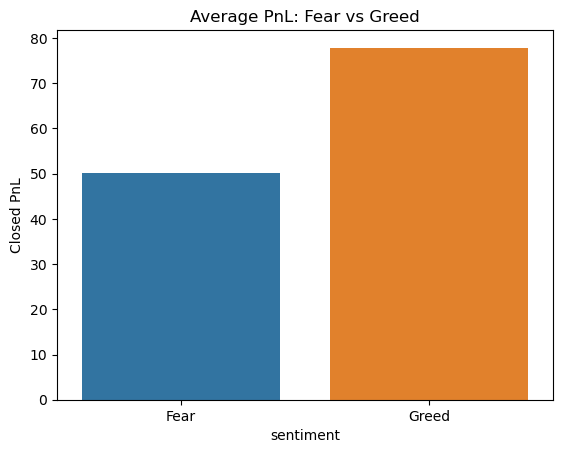

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=pnl_sentiment, x='sentiment', y='Closed PnL')
plt.title("Average PnL: Fear vs Greed")
plt.show()

In [32]:
analysis_df['win'] = (analysis_df['Closed PnL'] > 0).astype(int)

win_rate_sentiment = (
    analysis_df.groupby('sentiment')['win']
    .mean()
    .reset_index()
)



C:\Users\RP DIGIPRESS\AppData\Local\Temp\ipykernel_5860\3788407647.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  analysis_df['win'] = (analysis_df['Closed PnL'] > 0).astype(int)


In [33]:
print(win_rate_sentiment)


  sentiment       win
0      Fear  0.415146
1     Greed  0.453492


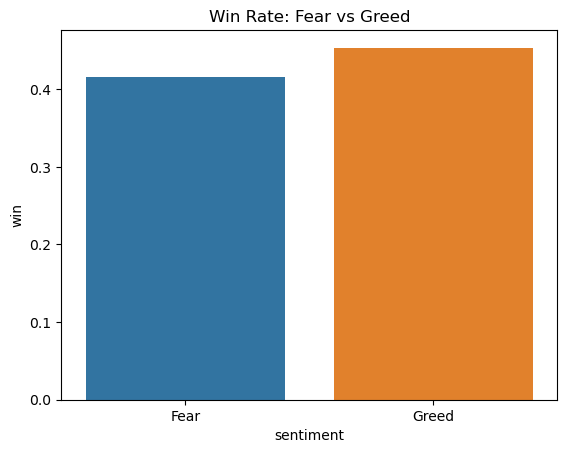

In [34]:
sns.barplot(data=win_rate_sentiment, x='sentiment', y='win')
plt.title("Win Rate: Fear vs Greed")
plt.show()

In [35]:
drawdown_proxy = (
    analysis_df.groupby('sentiment')['Closed PnL']
    .std()
    .reset_index()
)

print(drawdown_proxy)

  sentiment   Closed PnL
0      Fear   909.121796
1     Greed  1059.262203


QUESTION 2
Do traders change behavior based on sentiment?

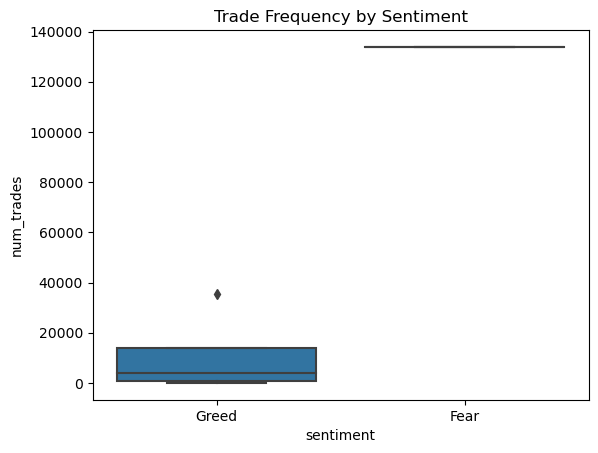

In [36]:
trades_per_day = (
    analysis_df.groupby(['date', 'sentiment'])
    .size()
    .reset_index(name='num_trades')
)

sns.boxplot(data=trades_per_day, x='sentiment', y='num_trades')
plt.title("Trade Frequency by Sentiment")
plt.show()

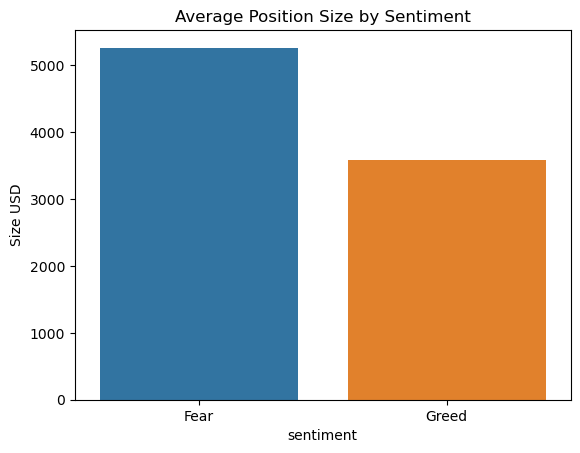

In [37]:
size_sentiment = (
    analysis_df.groupby('sentiment')['Size USD']
    .mean()
    .reset_index()
)

sns.barplot(data=size_sentiment, x='sentiment', y='Size USD')
plt.title("Average Position Size by Sentiment")
plt.show()

In [38]:
long_short = (
    analysis_df.groupby(['sentiment', 'Side'])
    .size()
    .unstack()
    .fillna(0)
)

long_short['long_ratio'] = long_short['BUY'] / (long_short['BUY'] + long_short['SELL'])

print(long_short)

Side         BUY   SELL  long_ratio
sentiment                          
Fear       66081  67790    0.493617
Greed      18792  24459    0.434487


QUESTION 3
Identify 2–3 Trader Segments

In [39]:
trade_counts = merged.groupby('Account').size()

threshold = trade_counts.median()

frequent_traders = trade_counts[trade_counts > threshold].index

merged['trader_type'] = np.where(
    merged['Account'].isin(frequent_traders),
    'Frequent',
    'Infrequent'
)

freq_perf = (
    merged.groupby('trader_type')['Closed PnL']
    .mean()
    .reset_index()
)

print(freq_perf)

  trader_type  Closed PnL
0    Frequent   42.493421
1  Infrequent   96.943024


In [40]:
win_rate_by_trader = (
    merged.groupby('Account')['win']
    .mean()
)

consistent_threshold = win_rate_by_trader.median()

merged['consistency_group'] = np.where(
    merged['Account'].map(win_rate_by_trader) > consistent_threshold,
    'Consistent',
    'Inconsistent'
)

consistency_perf = (
    merged.groupby('consistency_group')['Closed PnL']
    .mean()
    .reset_index()
)

print(consistency_perf)

  consistency_group  Closed PnL
0        Consistent   38.783637
1      Inconsistent   62.488537


PART C


In [41]:
median_win = merged.groupby('Account')['win'].mean().median()

merged['trader_quality'] = np.where(
    merged.groupby('Account')['win'].transform('mean') > median_win,
    'High Win',
    'Low Win'
)

merged['adjusted_size'] = merged['Size USD']

merged.loc[
    (merged['sentiment'] == 'Fear') &
    (merged['trader_quality'] == 'Low Win'),
    'adjusted_size'
] = merged['Size USD'] * 0.75

In [42]:

win_rate_by_trader = merged.groupby('Account')['win'].mean()

median_win = win_rate_by_trader.median()

merged['consistency_group'] = np.where(
    merged['Account'].map(win_rate_by_trader) > median_win,
    'Consistent',
    'Inconsistent'
)

In [43]:
win_rate_by_trader.head()

Account
0x083384f897ee0f19899168e3b1bec365f52a9012    0.359612
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd    0.442720
0x271b280974205ca63b716753467d5a371de622ab    0.301917
0x28736f43f1e871e6aa8b1148d38d4994275d72c4    0.438585
0x2c229d22b100a7beb69122eed721cee9b24011dd    0.519914
Name: win, dtype: float64

In [44]:
merged['greed_adjusted_size'] = merged['Size USD']

merged.loc[
    (merged['sentiment'] == 'Greed') &
    (merged['consistency_group'] == 'Consistent'),
    'greed_adjusted_size'
] = merged['Size USD'] * 1.15



In [45]:
merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,timestamp,value,classification,win,sentiment,trader_type,consistency_group,trader_quality,adjusted_size,greed_adjusted_size
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,...,2024-10-27 05:30:00,74.0,Greed,0,Greed,Infrequent,Consistent,High Win,7872.16,9052.9840
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,...,2024-10-27 05:30:00,74.0,Greed,0,Greed,Infrequent,Consistent,High Win,127.68,146.8320
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,...,2024-10-27 05:30:00,74.0,Greed,0,Greed,Infrequent,Consistent,High Win,1150.63,1323.2245
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,...,2024-10-27 05:30:00,74.0,Greed,0,Greed,Infrequent,Consistent,High Win,1142.04,1313.3460
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,...,2024-10-27 05:30:00,74.0,Greed,0,Greed,Infrequent,Consistent,High Win,69.75,80.2125


BONUS

In [46]:

daily_trader = merged.groupby(['Account', 'date']).agg({
    'Closed PnL': 'sum',
    'Size USD': 'mean',
    'win': 'mean',
    'sentiment': 'first'
}).reset_index()

daily_trader.rename(columns={
    'Closed PnL': 'daily_pnl',
    'Size USD': 'avg_size',
    'win': 'win_rate'
}, inplace=True)

In [47]:
daily_trader = daily_trader.sort_values(['Account', 'date'])


daily_trader['next_day_pnl'] = daily_trader.groupby('Account')['daily_pnl'].shift(-1)

daily_trader['target'] = pd.cut(
    daily_trader['next_day_pnl'],
    bins=[-np.inf, -10, 10, np.inf],
    labels=['Loss', 'Neutral', 'Profit']
)

daily_trader = daily_trader.dropna()

In [48]:
daily_trader['sentiment_encoded'] = daily_trader['sentiment'].map({
    'Fear': 0,
    'Neutral': 1,
    'Greed': 2
})

In [49]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

features = ['daily_pnl', 'avg_size', 'win_rate', 'sentiment_encoded']

X = daily_trader[features]
y = daily_trader['target']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)

print("Model Accuracy:", round(accuracy, 3))

Model Accuracy: 0.571


In [50]:
trader_features = merged.groupby('Account').agg({
    'Closed PnL': 'mean',
    'Size USD': 'mean',
    'win': 'mean'
}).reset_index()

trader_features.rename(columns={
    'Closed PnL': 'avg_pnl',
    'Size USD': 'avg_size',
    'win': 'win_rate'
}, inplace=True)

In [51]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(
    trader_features[['avg_pnl', 'avg_size', 'win_rate']]
)

kmeans = KMeans(n_clusters=3, random_state=42)
trader_features['cluster'] = kmeans.fit_predict(scaled_data)

c:\Users\RP DIGIPRESS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\RP DIGIPRESS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [52]:

cluster_summary = trader_features.groupby('cluster').mean(numeric_only=True)
print(cluster_summary)

            avg_pnl      avg_size  win_rate
cluster                                    
0         49.302560   3548.222060  0.415283
1        365.725364   6619.420645  0.346208
2         38.024405  24666.435723  0.400056
